# Pandas Expressions

Using `pd.col()` expressions (pandas 3.0+) with `mplchart` on the pandas backend.
`pd.col()` returns a `pandas.api.typing.Expression` that plugs directly into `Chart.plot` — no lambda needed.

In [1]:
import pandas as pd
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, LinePlot

prices = sample_prices()

## Column reference

Plot a single column directly.

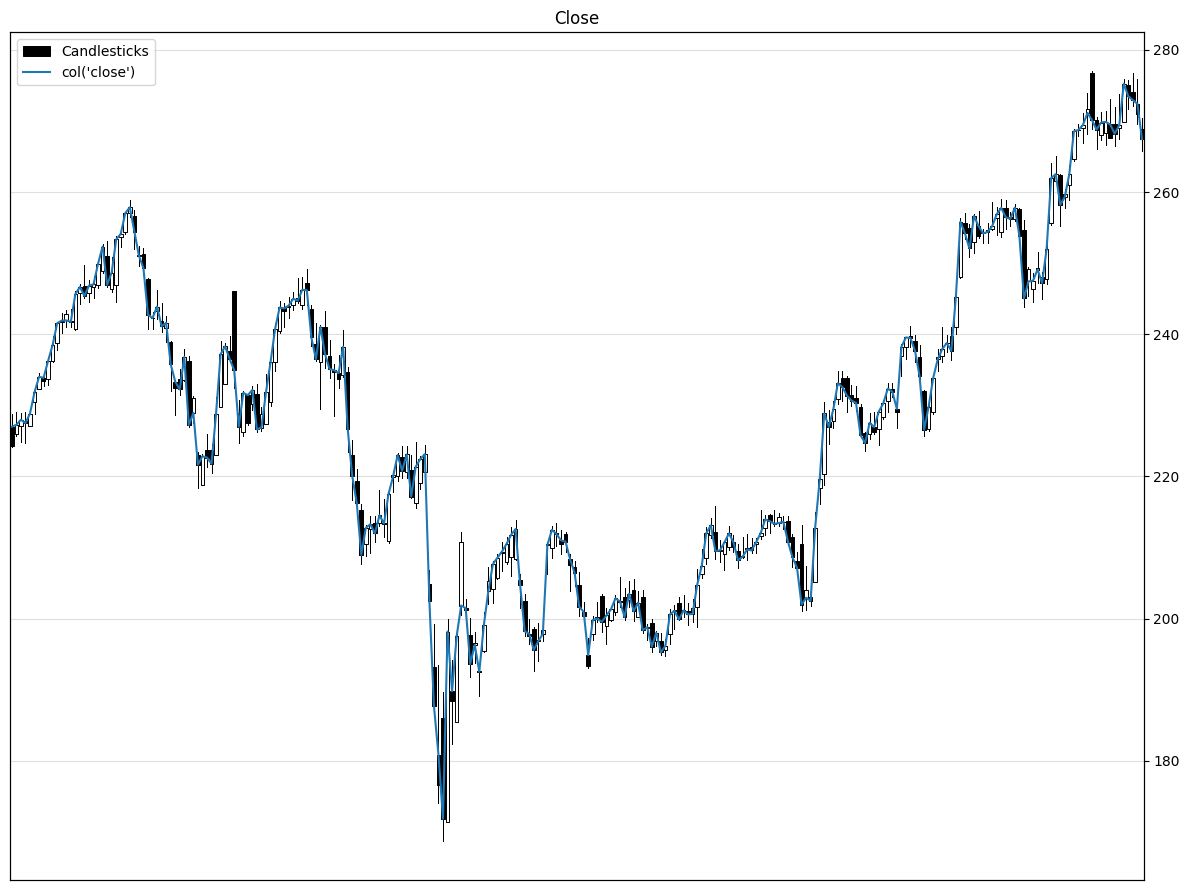

In [2]:
Chart(prices, title="Close", max_bars=250).plot(
    Candlesticks(),
    pd.col("close"),
).show()

## Rolling mean

Compute a moving average inline — no indicator class needed.

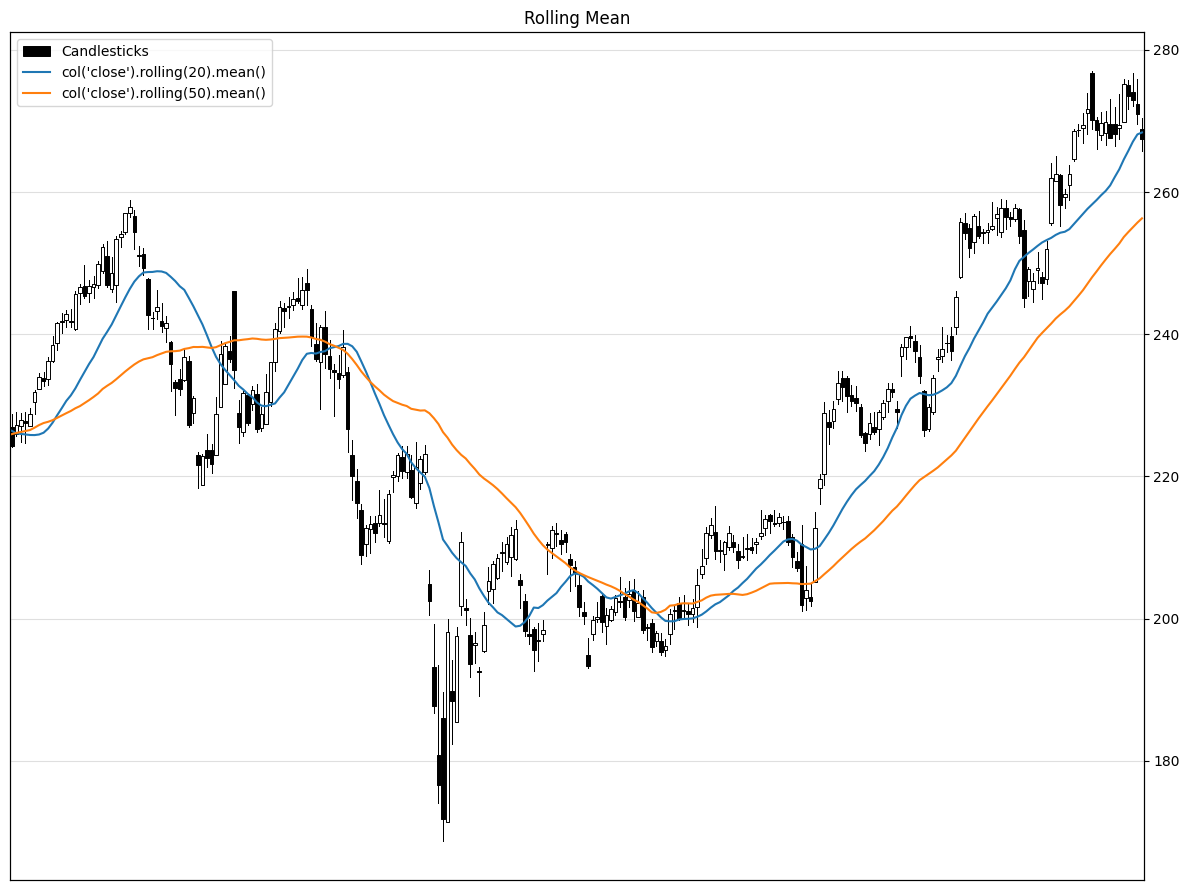

In [3]:
Chart(prices, title="Rolling Mean", max_bars=250).plot(
    Candlesticks(),
    pd.col("close").rolling(20).mean(),
    pd.col("close").rolling(50).mean(),
).show()

## Derived expression

Combine columns — here the candle body size (absolute open-to-close range).

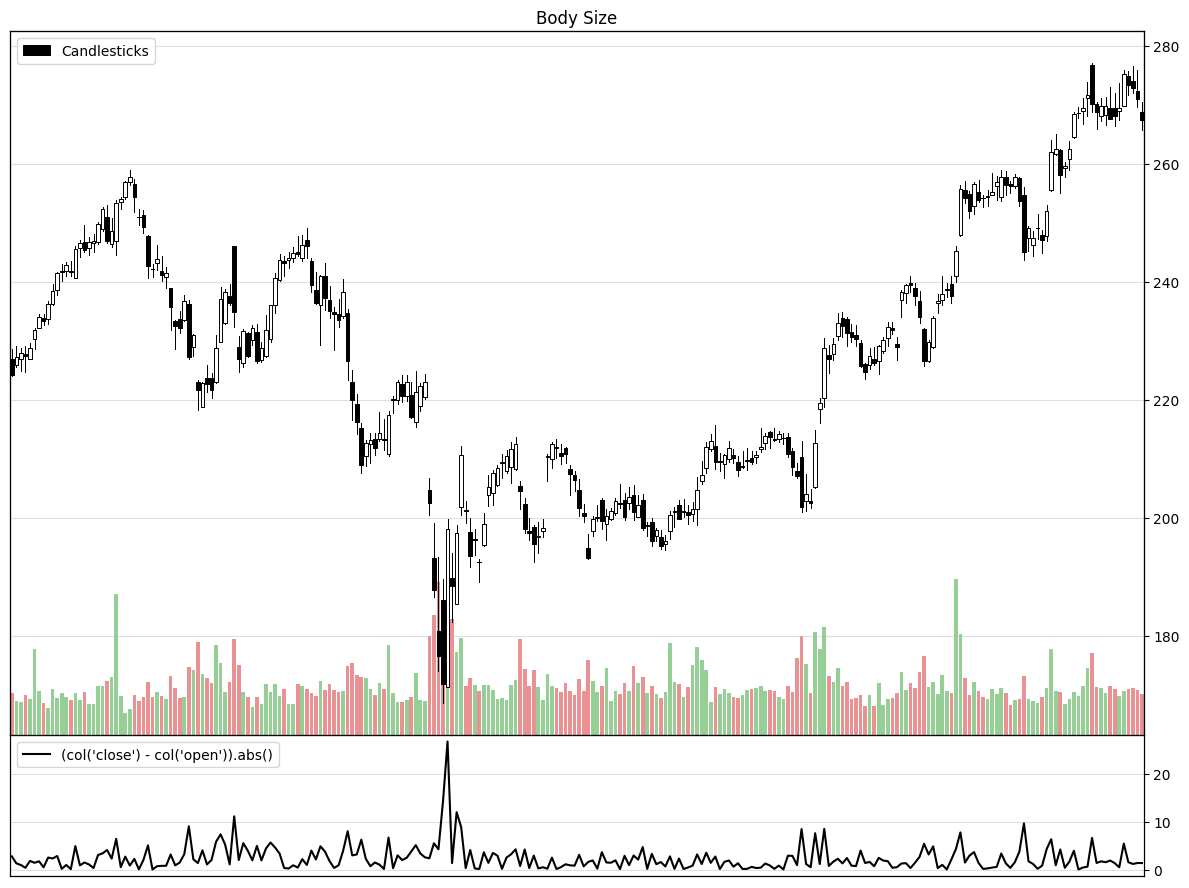

In [4]:
body = (pd.col("close") - pd.col("open")).abs()

Chart(prices, title="Body Size", max_bars=250).plot(
    Candlesticks(),
    Volume(),
).pane("below").plot(
    body,
).show()